In [ ]:
# Colab Step 1: mount Drive, load files, merge expression & mutation, create IDH1 status sheet
from google.colab import drive
drive.mount('/content/drive')

import os, glob
import pandas as pd
import numpy as np

# --------- Edit this path if your folder is in a different location ----------
DRIVE_FOLDER = "/content/drive/MyDrive/TCGA_Mutation_Shift_Biology"
# ---------------------------------------------------------------------------

# list files in folder for user confirmation
print("Files in folder:")
for p in sorted(glob.glob(os.path.join(DRIVE_FOLDER, "*"))):
    print(" ", os.path.basename(p))
print()

# ---------- Load expression files (assumes two star_fpkm-uq tsvs) ----------
# adapt filenames if exact names differ
exp_files = sorted([f for f in glob.glob(os.path.join(DRIVE_FOLDER, "*star_fpkm-uq*.tsv"))])
if len(exp_files) == 0:
    exp_files = sorted([f for f in glob.glob(os.path.join(DRIVE_FOLDER, "*.tsv")) if "fpkm" in os.path.basename(f).lower()])
print("Expression files found:", exp_files)
assert len(exp_files) >= 1, "No expression files found matching '*star_fpkm-uq*.tsv' — check filenames."

# read and merge column-wise
expr_list = []
for ef in exp_files:
    print("Loading expression:", ef)
    # Xena tsvs usually have gene identifiers as index
    tmp = pd.read_csv(ef, sep="\t", index_col=0)
    expr_list.append(tmp)
# concat columns (samples)
expr = pd.concat(expr_list, axis=1, join='outer')
print("Merged expression shape (genes x samples):", expr.shape)

# standardize gene index: strip ENSG version suffix if present (e.g., ENSG000001234.5 -> ENSG000001234)
expr.index = expr.index.astype(str).str.split('.').str[0]

# ---------- Load mutation files (assumes two somaticmutation_wxs tsvs) ----------
mut_files = sorted([f for f in glob.glob(os.path.join(DRIVE_FOLDER, "*somaticmutation_wxs*.tsv"))])
print("Mutation files found:", mut_files)
assert len(mut_files) >= 1, "No mutation files found matching '*somaticmutation_wxs*.tsv' — check filenames."

mut_list = []
for mf in mut_files:
    print("Loading mutation file:", mf)
    tmpm = pd.read_csv(mf, sep="\t", low_memory=False)
    mut_list.append(tmpm)
mut = pd.concat(mut_list, axis=0, ignore_index=True)
print("Merged mutation table shape (rows=mutations):", mut.shape)
print("Mutation table columns:", list(mut.columns)[:20])

# ---------- Normalize sample barcodes to first 15 chars ----------
# For expression: column names are barcodes
expr.columns = [str(c)[:15] for c in expr.columns]
# For mutation: detect the sample/barcode column robustly
possible_sample_cols = [c for c in mut.columns if c.lower() in ("sample","tumor_sample_barcode","tumor_sample_barcode","tumor_sample_barcode")]
# fallback detection heuristics
if len(possible_sample_cols) == 0:
    # find any column that contains strings starting with 'TCGA-'
    for c in mut.columns:
        sample_vals = mut[c].astype(str).head(50).values
        if any(v.startswith("TCGA-") for v in sample_vals):
            possible_sample_cols = [c]
            break
assert len(possible_sample_cols) >= 1, "Could not find sample/barcode column in mutation table. Please inspect mutation table columns."
mut_sample_col = possible_sample_cols[0]
print("Using mutation sample column:", mut_sample_col)

# create a unified 'sample' column of 15-char IDs
mut['sample'] = mut[mut_sample_col].astype(str).str[:15]

# Detect gene column (Hugo_Symbol / gene)
possible_gene_cols = [c for c in mut.columns if c.lower() in ("hugo_symbol","gene","gene_name","symbol")]
if len(possible_gene_cols) == 0:
    # heuristic: find column whose values include 'IDH1'
    for c in mut.columns:
        vals = mut[c].astype(str).unique()[:20]
        if "IDH1" in vals:
            possible_gene_cols = [c]
            break
assert len(possible_gene_cols) >= 1, "Could not find gene/Hugo_Symbol column in mutation table. Please inspect mutation table columns."
mut_gene_col = possible_gene_cols[0]
print("Using mutation gene column:", mut_gene_col)

# ---------- Build IDH1 mutated-sample list ----------
idh_rows = mut[mut[mut_gene_col].astype(str) == "IDH1"]
idh_samples = idh_rows['sample'].unique().tolist()
print("Number of unique samples with IDH1 mutation detected in merged mutation table:", len(idh_samples))

# ---------- Load gene signature Excel and prepare mapping ----------
sig_xls_path = os.path.join(DRIVE_FOLDER, "gene_list_signature.xlsx")
if not os.path.exists(sig_xls_path):
    sig_xls_path = os.path.join(DRIVE_FOLDER, "gene_list_signature.xlsx")  # fallback
assert os.path.exists(sig_xls_path), f"Signature Excel not found at {sig_xls_path} — check filename."

sig_df = pd.read_excel(sig_xls_path, engine='openpyxl')
# assume Column A = Ensembl ID, Column B = Gene Name
# rename columns to expected names if needed
if sig_df.shape[1] >= 2:
    sig_df = sig_df.iloc[:, :2]
    sig_df.columns = ["ensembl_id", "gene_name"]
else:
    raise AssertionError("Signature Excel must have at least two columns (Ensembl ID in col A, Gene Name in col B).")

# strip version in ensembl IDs
sig_df['ensembl_id'] = sig_df['ensembl_id'].astype(str).str.split('.').str[0]
print("Signature gene count (rows):", sig_df.shape[0])

# Map expression rownames (which may be ENSG or gene symbols)
# If expr index looks like ENSG IDs, we can map; else if gene symbols, we'll try to match by gene_name
sample_idx_preview = expr.index[:5].tolist()
print("Preview of expression index (first 5):", sample_idx_preview)

# Determine if expression rows are ENSG or gene symbols
is_ensg = all(str(i).upper().startswith("ENSG") for i in expr.index[:20])

if is_ensg:
    # subset expression to signature Ensembl IDs
    signature_ens = sig_df['ensembl_id'].tolist()
    sig_expr = expr.loc[expr.index.intersection(signature_ens)]
    # map row index to gene symbols where possible
    mapping = dict(zip(sig_df['ensembl_id'], sig_df['gene_name']))
    sig_expr = sig_expr.rename(index=mapping)
else:
    # assume expr index are gene symbols, map by gene_name
    signature_genes = sig_df['gene_name'].astype(str).tolist()
    sig_expr = expr.loc[expr.index.intersection(signature_genes)]
    # if Ensembl provided, ignore it
print("Signature expression matrix shape (genes x samples):", sig_expr.shape)

# ---------- Create IDH1 status table (one row per sample) ----------
all_samples = sorted(list(expr.columns))
idh_status = pd.DataFrame({
    "sample": all_samples,
    "IDH1_status": ["MT" if s in idh_samples else "WT" for s in all_samples]
})
print("Total expression samples:", len(all_samples))
print("Samples marked MT:", idh_status['IDH1_status'].value_counts().to_dict())

# Save results to Drive folder for later steps
out_fname1 = os.path.join(DRIVE_FOLDER, "merged_expression_genes_x_samples.tsv")
out_fname2 = os.path.join(DRIVE_FOLDER, "merged_mutation_table.tsv")
out_fname3 = os.path.join(DRIVE_FOLDER, "IDH1_status_table.csv")
out_fname4 = os.path.join(DRIVE_FOLDER, "signature_expression_genes_x_samples.tsv")

expr.to_csv(out_fname1, sep="\t")
mut.to_csv(out_fname2, sep="\t", index=False)
idh_status.to_csv(out_fname3, index=False)
sig_expr.to_csv(out_fname4, sep="\t")

print("\nSaved merged files to Drive:")
print(" ", out_fname1)
print(" ", out_fname2)
print(" ", out_fname3)
print(" ", out_fname4)
print("\nStep 1 COMPLETE: If shapes look reasonable, reply 'Step 1 done' and paste the printed summary above. Then I will give the next Colab cell (compute signature scores and WT vs MT comparisons).")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Files in folder:
  TCGA-GBM.somaticmutation_wxs.tsv
  TCGA-GBM.star_fpkm-uq.tsv
  TCGA-LGG.somaticmutation_wxs.tsv
  TCGA-LGG.star_fpkm-uq.tsv
  gene_list_signature.xlsx

Expression files found: ['/content/drive/MyDrive/TCGA_Mutation_Shift_Biology/TCGA-GBM.star_fpkm-uq.tsv', '/content/drive/MyDrive/TCGA_Mutation_Shift_Biology/TCGA-LGG.star_fpkm-uq.tsv']
Loading expression: /content/drive/MyDrive/TCGA_Mutation_Shift_Biology/TCGA-GBM.star_fpkm-uq.tsv
Loading expression: /content/drive/MyDrive/TCGA_Mutation_Shift_Biology/TCGA-LGG.star_fpkm-uq.tsv
Merged expression shape (genes x samples): (60660, 709)
Mutation files found: ['/content/drive/MyDrive/TCGA_Mutation_Shift_Biology/TCGA-GBM.somaticmutation_wxs.tsv', '/content/drive/MyDrive/TCGA_Mutation_Shift_Biology/TCGA-LGG.somaticmutation_wxs.tsv']
Loading mutation file: /content/drive/MyDrive/TCGA_Mutation_Shift_Bi

In [ ]:
# Colab diagnostic + mapping cell for signature mismatch
import os, glob
import pandas as pd
import numpy as np

DRIVE_FOLDER = "/content/drive/MyDrive/TCGA_Mutation_Shift_Biology"
expr_path = os.path.join(DRIVE_FOLDER, "merged_expression_genes_x_samples.tsv")
sig_xls_path = os.path.join(DRIVE_FOLDER, "gene_list_signature.xlsx")
out_sig_expr = os.path.join(DRIVE_FOLDER, "signature_expression_genes_x_samples.tsv")

print("Loading files...")
expr = pd.read_csv(expr_path, sep="\t", index_col=0)
sig_df = pd.read_excel(sig_xls_path, engine='openpyxl', dtype=str)

# Normalise sig_df columns (assume col1 = Ensembl, col2 = gene symbol)
if sig_df.shape[1] >= 2:
    sig_df = sig_df.iloc[:, :2]
    sig_df.columns = ["ensembl_id", "gene_name"]
else:
    raise ValueError("Signature Excel must have at least two columns (Ensembl ID in col A, Gene Name in col B).")

# Clean signature ids
sig_df['ensembl_id_clean'] = sig_df['ensembl_id'].astype(str).str.strip().str.split('.').str[0]
sig_df['gene_name_clean'] = sig_df['gene_name'].astype(str).str.strip()

# Quick previews
print("\n--- Preview expression index (first 30) ---")
for i in list(expr.index[:30]):
    print(" ", i)
print("\nTotal genes in expression:", expr.shape[0])

print("\n--- Preview signature (first 20 rows) ---")
print(sig_df.head(20).to_string(index=False))

# Determine expression index format
expr_idx_sample = [str(x) for x in expr.index[:200]]
is_ensg_like = sum(1 for x in expr_idx_sample if x.upper().startswith("ENSG")) / len(expr_idx_sample)
contains_pipe = sum(1 for x in expr_idx_sample if '|' in x) / len(expr_idx_sample)

print(f"\nInference: fraction of first 200 expr rows starting with 'ENSG' = {is_ensg_like:.2f}")
print(f"          fraction containing '|' = {contains_pipe:.2f}")

# Prepare possible expression-gene representations for matching
expr_index = expr.index.astype(str)

# 1) Try direct Ensembl match (strip versions in both)
expr_ens_nover = expr_index.str.split('.').str[0]
sig_ens = sig_df['ensembl_id_clean'].astype(str)

match_ens = set(expr_ens_nover).intersection(set(sig_ens))
print(f"\nMethod 1 - Ensembl (no version) overlap: {len(match_ens)} genes matched")

# 2) Try direct gene symbol match (case-insensitive)
expr_symbols = expr_index.str.upper()
sig_symbols = sig_df['gene_name_clean'].str.upper()

match_sym = set(expr_symbols).intersection(set(sig_symbols))
print(f"Method 2 - Gene symbol (case-insensitive) overlap: {len(match_sym)} genes matched")

# 3) If expr rows contain '|' or other separators, try extracting symbol after '|' or last token
extracted_symbols = expr_index.str.split('|').str[-1].str.split().str[0].str.upper()
match_extracted = set(extracted_symbols).intersection(set(sig_symbols))
print(f"Method 3 - Extracted symbol after '|'/first token overlap: {len(match_extracted)} genes matched")

# 4) If expr rows are 'ENSG|SYMBOL' style, try to map Ensembl portion and symbol portion
expr_ens_frompipe = expr_index.str.split('|').str[0].str.split('.').str[0]
expr_sym_frompipe = expr_index.str.split('|').str[-1].str.split().str[0].str.upper()
match_ens_frompipe = set(expr_ens_frompipe).intersection(set(sig_ens))
match_sym_frompipe = set(expr_sym_frompipe).intersection(set(sig_symbols))
print(f"Method 4 - If 'ENSG|SYMBOL': ENSG-part matches = {len(match_ens_frompipe)}, SYMBOL-part matches = {len(match_sym_frompipe)}")

# Show up to 10 example matches/unmatched for each method
def sample_examples(sset, name, limit=10):
    s = sorted(list(sset))
    print(f"\n{name} (showing up to {limit} examples):")
    for v in s[:limit]:
        print(" ", v)

sample_examples(match_ens, "Ensembl matches (method 1)")
sample_examples(match_sym, "Symbol matches (method 2)")
sample_examples(match_extracted, "Extracted symbol matches (method 3)")

# Decide best matching strategy automatically (prefer Ensembl exact if >0, else symbol, else extracted)
chosen_method = None
if len(match_ens) > 0:
    chosen_method = 'ensembl_nover'
elif len(match_sym) > 0:
    chosen_method = 'symbol_ci'
elif len(match_extracted) > 0:
    chosen_method = 'extracted_symbol'
else:
    chosen_method = None

print("\nAuto-selected matching strategy:", chosen_method)

# Build signature expression matrix according to chosen strategy
if chosen_method == 'ensembl_nover':
    # Make a mapping from expr index (nover) -> original index
    expr_map = pd.Series(expr.index, index=expr_ens_nover).to_dict()
    matched_ens = sorted(list(match_ens))
    matched_expr_indices = [expr_map[e] for e in matched_ens]
    sig_expr = expr.loc[matched_expr_indices]
    # Rename rows to gene symbols from signature (if available)
    ensembl_to_symbol = dict(zip(sig_df['ensembl_id_clean'], sig_df['gene_name_clean']))
    # only rename matched ones
    new_index = [ensembl_to_symbol.get(e.split('.')[0], e) for e in [s.split('.')[0] for s in matched_ens]]
    sig_expr.index = new_index
    print(f"\nBuilt sig_expr with {sig_expr.shape[0]} genes using Ensembl mapping.")
elif chosen_method == 'symbol_ci':
    # map by symbols (case-insensitive)
    expr_index_upper = expr_index.str.upper()
    # build dict gene_upper -> original index
    expr_map_sym = pd.Series(expr.index, index=expr_index_upper).to_dict()
    matched_sym = sorted([s for s in sig_symbols if s in expr_map_sym])
    matched_expr_indices = [expr_map_sym[s] for s in matched_sym]
    sig_expr = expr.loc[matched_expr_indices]
    # rename indexes to canonical gene names from signature (upper->original)
    upper_to_signame = dict(zip(sig_df['gene_name_clean'].str.upper(), sig_df['gene_name_clean']))
    sig_expr.index = [upper_to_signame.get(s, s) for s in matched_sym]
    print(f"\nBuilt sig_expr with {sig_expr.shape[0]} genes using case-insensitive symbol matching.")
elif chosen_method == 'extracted_symbol':
    # mapping extracted->original index
    expr_map_ex = pd.Series(expr.index, index=extracted_symbols).to_dict()
    matched_ex = sorted([s for s in sig_symbols if s in expr_map_ex])
    matched_expr_indices = [expr_map_ex[s] for s in matched_ex]
    sig_expr = expr.loc[matched_expr_indices]
    upper_to_signame = dict(zip(sig_df['gene_name_clean'].str.upper(), sig_df['gene_name_clean']))
    sig_expr.index = [upper_to_signame.get(s, s) for s in matched_ex]
    print(f"\nBuilt sig_expr with {sig_expr.shape[0]} genes using extracted symbol matching.")
else:
    sig_expr = pd.DataFrame()  # empty

# Final report and save if non-empty
if sig_expr.shape[0] > 0:
    print("\nFinal signature expression shape (genes x samples):", sig_expr.shape)
    # Save to Drive for subsequent steps
    sig_expr.to_csv(out_sig_expr, sep="\t")
    print("Saved signature expression to:", out_sig_expr)
    # Show first few genes found
    print("\nFirst 20 signature genes found (new row names):")
    print(list(sig_expr.index[:20]))
else:
    print("\nNo matches found with automated heuristics.")
    print("Suggestions:")
    print("  1) Inspect the expression rownames (top of this output) and your gene_list_signature sheet.")
    print("  2) If your signature uses Ensembl IDs but expression uses gene symbols, ensure gene_list_signature has correct gene symbols in col B.")
    print("  3) If expression rows look like 'ENSG00000|SYMBOL' or 'ENSG00000 SYMBOL', tell me the exact format (paste the first 10 rows shown above) and I will adjust the parser.")
    print("  4) Alternatively, paste the first 20 rows of your signature Excel here (ensembl + gene) and I'll map them for you.")

print("\nDiagnostic complete. Please reply 'Diag done' and paste the lines showing:")
print(" - Total genes in expression (printed above)")
print(" - The three method overlap counts (Ensembl, symbol, extracted) as printed above.")

Loading files...

--- Preview expression index (first 30) ---
  ENSG00000000003
  ENSG00000000005
  ENSG00000000419
  ENSG00000000457
  ENSG00000000460
  ENSG00000000938
  ENSG00000000971
  ENSG00000001036
  ENSG00000001084
  ENSG00000001167
  ENSG00000001460
  ENSG00000001461
  ENSG00000001497
  ENSG00000001561
  ENSG00000001617
  ENSG00000001626
  ENSG00000001629
  ENSG00000001630
  ENSG00000001631
  ENSG00000002016
  ENSG00000002079
  ENSG00000002330
  ENSG00000002549
  ENSG00000002586
  ENSG00000002586
  ENSG00000002587
  ENSG00000002726
  ENSG00000002745
  ENSG00000002746
  ENSG00000002822

Total genes in expression: 60660

--- Preview signature (first 20 rows) ---
     ensembl_id gene_name ensembl_id_clean gene_name_clean
ENSG00000113492     AGXT2  ENSG00000113492           AGXT2
ENSG00000101444      AHCY  ENSG00000101444            AHCY
ENSG00000158467    AHCYL2  ENSG00000158467          AHCYL2
ENSG00000144908   ALDH1L1  ENSG00000144908         ALDH1L1
ENSG00000145020       AMT 

Mounted at /content/drive
Loaded saved signature_expression_for_scoring.tsv shape: (64, 704)
Loaded deduplicated expression: (60660, 704)
Signature expression columns are subset of dedup expression columns.
Final signature matrix shape used for scoring: (64, 704)
Saved signature_scores_meanZ_table.csv rows: 709
Stats: MT= 416 WT= 293 Mann-Whitney p= 4.229e-39 Cohen's d= -1.152


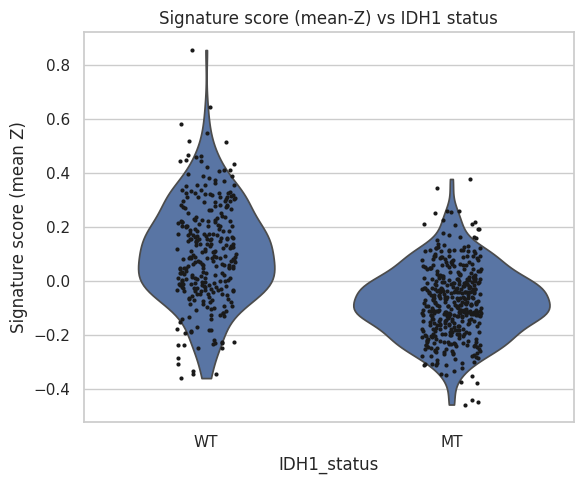

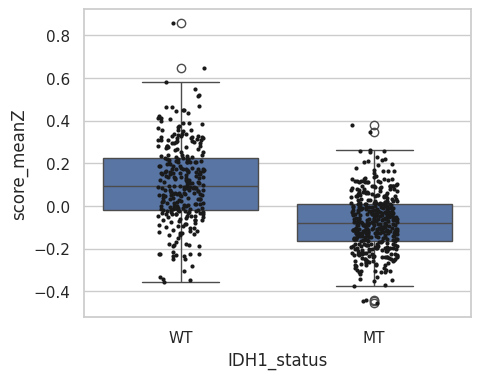

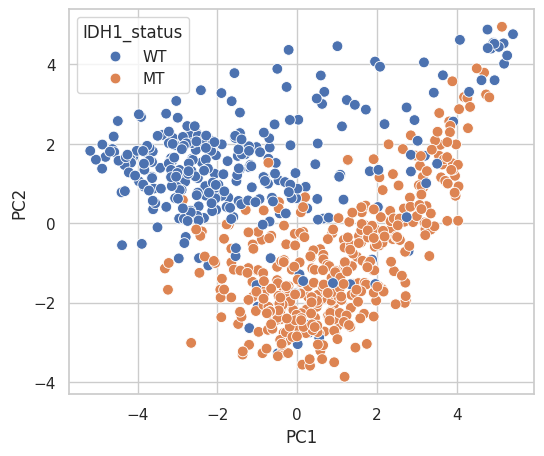


All final outputs saved to: /content/drive/MyDrive/TCGA_Mutation_Shift_Biology
Saved files:  signature_scores_meanZ_table.csv sig_violin_meanZ_final.png sig_box_meanZ_final.png


In [ ]:
# FINAL safe cell: use saved signature_expression_for_scoring.tsv to compute mean-Z, stats & plots.
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os, pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from scipy.stats import mannwhitneyu
from sklearn.decomposition import PCA
from math import sqrt

DRIVE_FOLDER = "/content/drive/MyDrive/TCGA_Mutation_Shift_Biology"

def collapse_duplicates_by_mean(df, trunc_len=15):
    truncated = [str(c)[:trunc_len] for c in df.columns]
    mapping = {}
    for orig, t in zip(df.columns, truncated):
        mapping.setdefault(t, []).append(orig)
    data = {}
    collapsed = {}
    for t, origs in mapping.items():
        if len(origs) == 1:
            data[t] = df[origs[0]].values
        else:
            data[t] = df[origs].mean(axis=1).values
            collapsed[t] = origs
    new_df = pd.DataFrame(data, index=df.index, columns=list(data.keys()))
    return new_df, collapsed

def cohen_d(a,b):
    a = np.asarray(a); b = np.asarray(b)
    na = len(a); nb = len(b)
    if na < 2 or nb < 2:
        return np.nan
    pooled_sd = np.sqrt(((na-1)*np.var(a, ddof=1) + (nb-1)*np.var(b, ddof=1)) / (na+nb-2))
    return (np.mean(a) - np.mean(b)) / pooled_sd

# paths
sig_expr_saved = os.path.join(DRIVE_FOLDER, "signature_expression_for_scoring.tsv")
expr_dedup_saved = os.path.join(DRIVE_FOLDER, "merged_expression_dedup_cols.tsv")
expr_merged_raw = os.path.join(DRIVE_FOLDER, "merged_expression_genes_x_samples.tsv")
idh_path = os.path.join(DRIVE_FOLDER, "IDH1_status_table.csv")

# load IDH status
if not os.path.exists(idh_path):
    raise FileNotFoundError("IDH1_status_table.csv missing. Please generate it earlier.")
idh = pd.read_csv(idh_path)
idh['sample'] = idh['sample'].astype(str).str[:15]

# load signature expression (preferred)
if os.path.exists(sig_expr_saved):
    sig_expr = pd.read_csv(sig_expr_saved, sep="\t", index_col=0)
    print("Loaded saved signature_expression_for_scoring.tsv shape:", sig_expr.shape)
else:
    raise FileNotFoundError("signature_expression_for_scoring.tsv not found. Please run earlier mapping step or provide file.")

# load deduplicated expression if exists else build from raw merged
if os.path.exists(expr_dedup_saved):
    expr = pd.read_csv(expr_dedup_saved, sep="\t", index_col=0)
    print("Loaded deduplicated expression:", expr.shape)
else:
    if not os.path.exists(expr_merged_raw):
        raise FileNotFoundError("No expression file found to deduplicate.")
    expr_raw = pd.read_csv(expr_merged_raw, sep="\t", index_col=0)
    expr, collapsed = collapse_duplicates_by_mean(expr_raw, trunc_len=15)
    expr.to_csv(expr_dedup_saved, sep="\t")
    print("Created and saved deduplicated expression:", expr.shape)
    if len(collapsed)>0:
        print("Collapsed examples:", list(collapsed.items())[:6])

# Ensure columns/sample names are patient-level 15-char
expr.columns = [str(c)[:15] for c in expr.columns]
sig_expr.columns = [str(c)[:15] for c in sig_expr.columns]

# If signature rows are gene symbols but expr index are ENSG, try to align by using the saved sig_expr rows:
# sig_expr should already contain the matched genes (we loaded it), so we use those rows directly.
# But ensure those genes exist in expr index or that sig_expr already contains sample columns.
if set(sig_expr.columns).issubset(set(expr.columns)):
    # signature matrix uses same sample columns as expr -> good
    print("Signature expression columns are subset of dedup expression columns.")
else:
    # If not, intersect on samples
    common_samples = sorted(list(set(sig_expr.columns).intersection(set(expr.columns))))
    if len(common_samples) == 0:
        raise ValueError("No overlapping samples between saved signature matrix and dedup expression after truncation.")
    # subset both
    sig_expr = sig_expr[common_samples]
    expr = expr[common_samples]
    print("Subsetted to common samples, n_samples =", len(common_samples))

# Final check: signature genes x samples
print("Final signature matrix shape used for scoring:", sig_expr.shape)

# compute mean-Z: z each gene across samples, then mean per sample
sig_z = sig_expr.astype(float).sub(sig_expr.astype(float).mean(axis=1), axis=0).div(sig_expr.astype(float).std(axis=1).replace(0, np.nan), axis=0)
score_meanZ = sig_z.mean(axis=0)
score_meanZ.index = [str(i)[:15] for i in score_meanZ.index]

# build results table
common_samples = sorted(list(set(score_meanZ.index).intersection(set(idh['sample']))))
res = pd.DataFrame({"sample": common_samples})
res['score_meanZ'] = score_meanZ.reindex(common_samples).values
res = res.merge(idh[['sample','IDH1_status']], on='sample', how='left')

# save outputs
out_scores = os.path.join(DRIVE_FOLDER, "signature_scores_meanZ_table.csv")
res.to_csv(out_scores, index=False)
print("Saved signature_scores_meanZ_table.csv rows:", res.shape[0])

# stats
group_mt = res[res['IDH1_status']=="MT"]['score_meanZ'].dropna()
group_wt = res[res['IDH1_status']=="WT"]['score_meanZ'].dropna()
if len(group_mt)>=2 and len(group_wt)>=2:
    u,p = mannwhitneyu(group_mt, group_wt)
    d = cohen_d(group_mt.values, group_wt.values)
    print("Stats: MT=",len(group_mt),"WT=",len(group_wt),"Mann-Whitney p=",f"{p:.3e}","Cohen's d=",f"{d:.3f}")
    with open(os.path.join(DRIVE_FOLDER, "sig_meanZ_stats.txt"), "w") as fh:
        fh.write(f"MT={len(group_mt)} WT={len(group_wt)} Mann-Whitney p={p:.6e} Cohen_d={d:.4f}\n")
else:
    print("Not enough samples for stats.")

# plots
sns.set(style="whitegrid")
plt.figure(figsize=(6,5))
sns.violinplot(x="IDH1_status", y="score_meanZ", data=res, inner=None, cut=0)
sns.stripplot(x="IDH1_status", y="score_meanZ", data=res, color="k", size=3, jitter=0.12)
plt.title("Signature score (mean-Z) vs IDH1 status")
plt.ylabel("Signature score (mean Z)")
plt.tight_layout()
vpath = os.path.join(DRIVE_FOLDER, "sig_violin_meanZ_final.png")
plt.savefig(vpath, dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(5,4))
sns.boxplot(x="IDH1_status", y="score_meanZ", data=res)
sns.stripplot(x="IDH1_status", y="score_meanZ", data=res, color="k", size=3, jitter=0.12)
bpath = os.path.join(DRIVE_FOLDER, "sig_box_meanZ_final.png")
plt.savefig(bpath, dpi=300, bbox_inches='tight')
plt.show()

# PCA if available
if sig_expr.shape[0] >= 2:
    common = [s for s in res['sample'].tolist() if s in sig_expr.columns]
    if len(common) >= 3:
        pca = PCA(n_components=2)
        pcs = pca.fit_transform(sig_expr[common].T.values)
        pc_df = pd.DataFrame({"PC1": pcs[:,0], "PC2": pcs[:,1], "sample": common})
        pc_df = pc_df.merge(res[['sample','IDH1_status']], on='sample', how='left')
        plt.figure(figsize=(6,5))
        sns.scatterplot(data=pc_df, x="PC1", y="PC2", hue="IDH1_status", s=60)
        ppath = os.path.join(DRIVE_FOLDER, "sig_pca_meanZ_final.png")
        plt.savefig(ppath, dpi=300, bbox_inches='tight')
        plt.show()
    else:
        print("PCA skipped: not enough common samples for PCA.")
else:
    print("PCA skipped: fewer than 2 signature genes present.")

print("\nAll final outputs saved to:", DRIVE_FOLDER)
print("Saved files: ", os.path.basename(out_scores), os.path.basename(vpath), os.path.basename(bpath))

In [ ]:
import pandas as pd, os
DR = "/content/drive/MyDrive/TCGA_Mutation_Shift_Biology"
tbl = pd.read_csv(os.path.join(DR, "signature_scores_meanZ_table.csv"))
print("rows in saved scores:", len(tbl))
print(tbl[['IDH1_status']].value_counts(dropna=False))
print("rows with NaN score_meanZ:", tbl['score_meanZ'].isna().sum())
# show samples with NaN score (if any)
print(tbl[tbl['score_meanZ'].isna()].head(10))
# if you want to keep only samples with a computed score:
tbl2 = tbl.dropna(subset=['score_meanZ'])
print("rows if restricted to scored samples:", len(tbl2))
# save trimmed version if you want
tbl2.to_csv(os.path.join(DR, "signature_scores_meanZ_table_scored_only.csv"), index=False)

rows in saved scores: 709
IDH1_status
MT             416
WT             293
Name: count, dtype: int64
rows with NaN score_meanZ: 0
Empty DataFrame
Columns: [sample, score_meanZ, IDH1_status]
Index: []
rows if restricted to scored samples: 709


expr samples: 704
score samples: 709
common samples (used, in expr order): 704
WT samples used: 291 MT samples used: 413
Saved: /content/drive/MyDrive/TCGA_Mutation_Shift_Biology/signature_gene_driver_analysis.csv


/tmp/ipython-input-735221295.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y="gene", x="cohen_d", data=top20, palette="coolwarm")


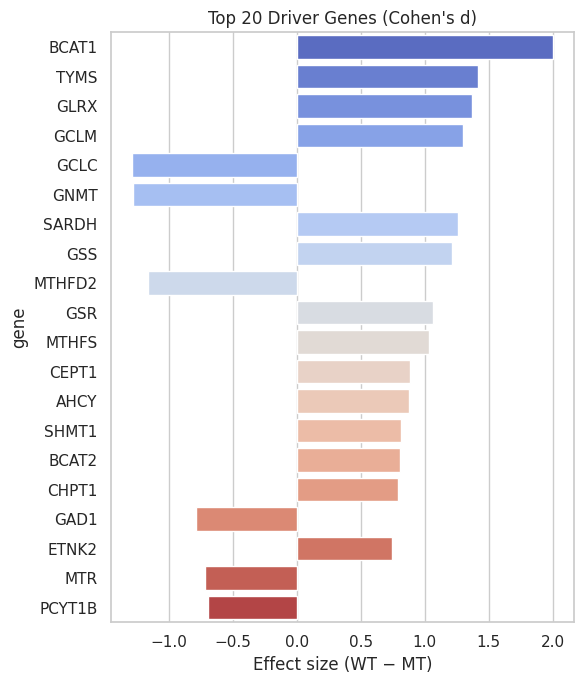

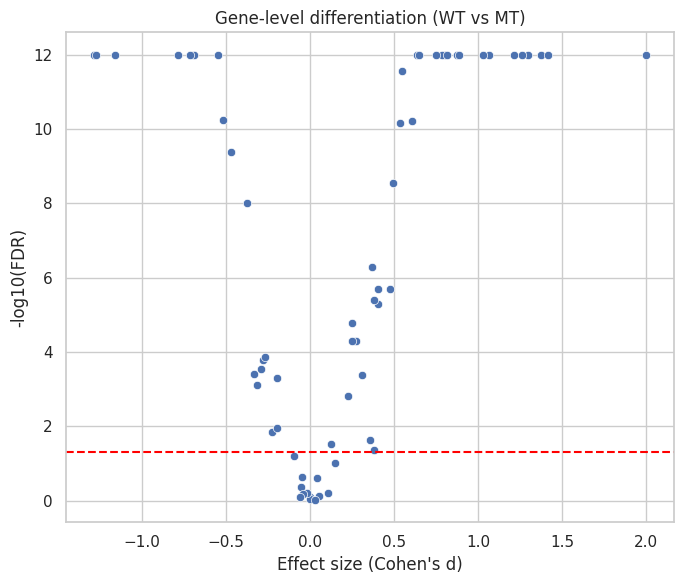

Done. Generated:
 - /content/drive/MyDrive/TCGA_Mutation_Shift_Biology/signature_gene_driver_analysis.csv
 - /content/drive/MyDrive/TCGA_Mutation_Shift_Biology/top20_driver_genes_effectsize.png
 - /content/drive/MyDrive/TCGA_Mutation_Shift_Biology/volcano_driver_genes.png


In [ ]:
# Robust per-gene driver analysis (avoids boolean-index alignment errors)
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu
from sklearn.decomposition import PCA
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import seaborn as sns

DR = "/content/drive/MyDrive/TCGA_Mutation_Shift_Biology"

# Load signature expression (genes x samples) - already matched
sig_expr = pd.read_csv(f"{DR}/signature_expression_for_scoring.tsv", sep="\t", index_col=0)

# Load scores / IDH table
scores = pd.read_csv(f"{DR}/signature_scores_meanZ_table.csv")

# Determine common samples (labels) and preserve order from expression matrix
expr_samples = list(sig_expr.columns.astype(str))
score_samples = list(scores['sample'].astype(str))
common_samples = [s for s in expr_samples if s in score_samples]   # keep expr order

print("expr samples:", len(expr_samples))
print("score samples:", len(score_samples))
print("common samples (used, in expr order):", len(common_samples))

# Subset expression and create IDH map (dict) for fast lookups
expr = sig_expr[common_samples]
idh_map = dict(zip(scores['sample'].astype(str), scores['IDH1_status'].astype(str)))

# Create explicit sample lists for WT and MT restricted to common_samples
wt_samples = [s for s in common_samples if idh_map.get(s) == "WT"]
mt_samples = [s for s in common_samples if idh_map.get(s) == "MT"]

print("WT samples used:", len(wt_samples), "MT samples used:", len(mt_samples))

# Z-transform per gene across the common samples
expr_z = expr.copy().astype(float).sub(expr.mean(axis=1), axis=0).div(expr.std(axis=1).replace(0, np.nan), axis=0)

# Compute per-gene stats using explicit sample label indexing
results = []
for gene in expr_z.index:
    vals = expr_z.loc[gene]
    wt_vals = vals[wt_samples]
    mt_vals = vals[mt_samples]

    # statistics
    delta = wt_vals.mean() - mt_vals.mean()
    s1, s2 = wt_vals.std(), mt_vals.std()
    n1, n2 = len(wt_vals), len(mt_vals)
    s_pooled = np.sqrt(((n1-1)*(s1**2) + (n2-1)*(s2**2)) / (n1+n2-2)) if (n1+n2-2)>0 else np.nan
    cohen_d = delta / s_pooled if (pd.notna(s_pooled) and s_pooled>0) else np.nan
    stat, p = mannwhitneyu(wt_vals, mt_vals, alternative="two-sided")

    results.append([gene, wt_vals.mean(), mt_vals.mean(), delta, cohen_d, p])

df = pd.DataFrame(results, columns=["gene","mean_WT","mean_MT","delta","cohen_d","p"])
df["FDR"] = multipletests(df["p"], method="fdr_bh")[1]

# PCA loadings (use expr_z transposed so samples x genes)
pca = PCA(n_components=3)
pca.fit(expr_z.T.values)
pc1_loadings = pd.Series(pca.components_[0], index=expr_z.index)
df["PC1_loading"] = df["gene"].map(pc1_loadings)

# Save results
out_csv = f"{DR}/signature_gene_driver_analysis.csv"
df.to_csv(out_csv, index=False)
print("Saved:", out_csv)

# Plot top 20 by absolute Cohen's d
top20 = df.reindex(df["cohen_d"].abs().sort_values(ascending=False).index).head(20)
plt.figure(figsize=(6,7))
sns.barplot(y="gene", x="cohen_d", data=top20, palette="coolwarm")
plt.title("Top 20 Driver Genes (Cohen's d)")
plt.xlabel("Effect size (WT − MT)")
plt.tight_layout()
plt.savefig(f"{DR}/top20_driver_genes_effectsize.png", dpi=300)
plt.show()

# Volcano plot
plt.figure(figsize=(7,6))
sns.scatterplot(x="cohen_d", y=-np.log10(df["FDR"]+1e-12), data=df)
plt.axhline(-np.log10(0.05), color="red", linestyle="--")
plt.title("Gene-level differentiation (WT vs MT)")
plt.xlabel("Effect size (Cohen's d)")
plt.ylabel("-log10(FDR)")
plt.tight_layout()
plt.savefig(f"{DR}/volcano_driver_genes.png", dpi=300)
plt.show()

print("Done. Generated:")
print(" -", out_csv)
print(" -", f"{DR}/top20_driver_genes_effectsize.png")
print(" -", f"{DR}/volcano_driver_genes.png")

New Code

In [ ]:
# ----------------- FINAL: TP53 / ATRX / TERT enrichment + stratified + logistic -----------------
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, scipy.stats as st
import statsmodels.api as sm
from statsmodels.tools.tools import add_constant

# ========== USER: change this path if your folder is elsewhere ==========
DR = "/content/drive/MyDrive/TCGA_Mutation_Shift_Biology"
# ======================================================================

# Input filenames (these are the aligned files you already created previously)
scores_fp = os.path.join(DR, "signature_scores_meanZ_table.csv")      # authoritative score file
merged_mut_fp = os.path.join(DR, "merged_mutation_table.tsv")         # merged mutation preview (sample,gene,...)

# Output prefix
out_prefix = os.path.join(DR, "TP53_ATRX_TERT_enrichment")

# Genes to analyze
genes = ["TP53","ATRX","TERT"]

# ----- Basic checks + load -----
if not os.path.exists(scores_fp):
    raise FileNotFoundError("Scores file not found: " + scores_fp)
if not os.path.exists(merged_mut_fp):
    raise FileNotFoundError("Merged mutation preview not found: " + merged_mut_fp)

scores = pd.read_csv(scores_fp, dtype=str)
if 'sample' not in scores.columns:
    raise ValueError("signature_scores_meanZ_table.csv must contain a 'sample' column")
# ensure there is a numeric score column
if 'score_meanZ' not in scores.columns:
    if 'score' in scores.columns:
        scores['score_meanZ'] = pd.to_numeric(scores['score'], errors='coerce')
    else:
        raise ValueError("score_meanZ (or score) column not found in signature_scores_meanZ_table.csv")

# harmonize sample IDs to first 12 chars (TCGA patient/sample)
scores['sample'] = scores['sample'].astype(str).str[:12]
scores = scores.set_index('sample', drop=False)
scores['score_meanZ'] = pd.to_numeric(scores['score_meanZ'], errors='coerce')

mut = pd.read_csv(merged_mut_fp, sep="\t", low_memory=False, dtype=str)
if 'sample' not in mut.columns or 'gene' not in mut.columns:
    raise ValueError("merged_mutation_table.tsv must contain 'sample' and 'gene' columns")
mut['sample'] = mut['sample'].astype(str).str[:12]

# ----- Build mutation sets and aligned matrix -----
mut_sets = { g: set(mut.loc[mut['gene']==g, 'sample'].dropna().unique()) for g in genes }

aligned = scores.copy()
for g in genes:
    aligned[g + "_mut"] = aligned.index.isin(mut_sets[g]).astype(int)

# Save aligned matrix
aligned_fp = os.path.join(DR, "aligned_scores_and_mutmatrix.tsv")
aligned.to_csv(aligned_fp, sep="\t", index=True)

# median grouping
median_val = aligned['score_meanZ'].median()
aligned['score_group_median'] = np.where(aligned['score_meanZ'] >= median_val, "High", "Low")
aligned['score_high_bin'] = (aligned['score_group_median']=="High").astype(int)

# helper function for stats
def compute_stats_for_df(df, gene_col):
    a = int(((df['score_group_median']=="High") & (df[gene_col]==1)).sum())
    b = int(((df['score_group_median']=="High") & (df[gene_col]==0)).sum())
    c = int(((df['score_group_median']=="Low") & (df[gene_col]==1)).sum())
    d = int(((df['score_group_median']=="Low") & (df[gene_col]==0)).sum())
    table = np.array([[a,b],[c,d]])
    # Fisher p
    try:
        fisher_p = st.fisher_exact(table, alternative='two-sided')[1]
    except Exception:
        fisher_p = np.nan
    # chi2
    try:
        chi2_p = st.chi2_contingency(table, correction=False)[1]
    except Exception:
        chi2_p = np.nan
    # Haldane-corrected OR
    t = table.astype(float) + 0.5
    OR_adj = (t[0,0]*t[1,1])/(t[0,1]*t[1,0])
    # Mann-Whitney
    mut_scores = df.loc[df[gene_col]==1, 'score_meanZ'].dropna().astype(float)
    nonmut_scores = df.loc[df[gene_col]==0, 'score_meanZ'].dropna().astype(float)
    if len(mut_scores) >= 2 and len(nonmut_scores) >= 2:
        try:
            mw_p = st.mannwhitneyu(mut_scores, nonmut_scores, alternative='two-sided')[1]
        except Exception:
            mw_p = np.nan
    else:
        mw_p = np.nan
    return {'High_mut':a, 'High_nonmut':b, 'Low_mut':c, 'Low_nonmut':d,
            'Fisher_p':fisher_p, 'Chi2_p':chi2_p, 'OR_adj':OR_adj, 'MW_p':mw_p,
            'total_mut_in_aligned': int(a+c)}

# create output folder if not exists
os.makedirs(DR, exist_ok=True)
sns.set(style="whitegrid")

# ---------------- A) Individual enrichment + plots ----------------
individual_rows = []
for g in genes:
    col = g + "_mut"
    stats = compute_stats_for_df(aligned, col)
    stats['gene'] = g
    individual_rows.append(stats)

indiv_df = pd.DataFrame(individual_rows)[['gene','High_mut','High_nonmut','Low_mut','Low_nonmut','Fisher_p','Chi2_p','OR_adj','MW_p','total_mut_in_aligned']]
indiv_fp = os.path.join(DR, out_prefix + "_individual_summary.csv")
indiv_df.to_csv(indiv_fp, index=False)

# plots per gene
for g in genes:
    col = g + "_mut"
    # fraction bar (High vs Low)
    frac = aligned.groupby('score_group_median')[col].agg(['sum','count']).reset_index()
    frac['frac'] = frac['sum'] / frac['count']
    fig, ax = plt.subplots(figsize=(4.5,4))
    sns.barplot(data=frac, x='score_group_median', y='frac', ax=ax)
    ax.set_title(f"{g} mutation fraction (High vs Low)")
    ax.set_xlabel("Score group (median)")
    ax.set_ylabel("Fraction mutated")
    plt.tight_layout()
    fig.savefig(os.path.join(DR, f"{g}_mut_frac_individual.png"), dpi=200)
    plt.close(fig)

    # violin of score by mutation status
    tmp = aligned[[col,'score_meanZ']].copy()
    tmp[col] = tmp[col].map({0:'Non-mut',1:'Mut'})
    fig, ax = plt.subplots(figsize=(5.5,4.5))
    sns.violinplot(x=col, y='score_meanZ', data=tmp, inner=None, ax=ax)
    sns.stripplot(x=col, y='score_meanZ', data=tmp, color='k', size=3, jitter=0.12, ax=ax)
    ax.set_title(f"{g}: signature score by mutation status")
    ax.set_xlabel(f"{g} mutation status")
    ax.set_ylabel("Signature score (mean Z)")
    plt.tight_layout()
    fig.savefig(os.path.join(DR, f"{g}_score_by_mut_individual.png"), dpi=200)
    plt.close(fig)

print("A) Individual enrichment complete:", indiv_fp)

# ---------------- B) Overall enrichment (combined table + plots) ----------------
overall_fp = os.path.join(DR, out_prefix + "_overall_summary.csv")
indiv_df.to_csv(overall_fp, index=False)

# combined fraction bar (genes side-by-side High vs Low)
frac_all = []
for g in genes:
    col = g + "_mut"
    tmp = aligned.groupby('score_group_median')[col].agg(['sum','count']).reset_index()
    tmp['gene'] = g
    tmp['frac'] = tmp['sum'] / tmp['count']
    frac_all.append(tmp)
frac_all_df = pd.concat(frac_all, ignore_index=True)
fig, ax = plt.subplots(figsize=(7,4.5))
sns.barplot(data=frac_all_df, x='gene', y='frac', hue='score_group_median', ax=ax)
ax.set_ylabel("Fraction mutated")
ax.set_title("Mutation fraction by gene (High vs Low)")
plt.tight_layout()
fig.savefig(os.path.join(DR, "combined_mut_frac_TP53_ATRX_TERT.png"), dpi=200)
plt.close(fig)

print("B) Overall enrichment complete:", overall_fp)

# ---------------- C) IDH1-stratified enrichment + plots ----------------
strat_fp = None
if 'IDH1_status' not in aligned.columns:
    print("Warning: IDH1_status not present in aligned matrix. Skipping IDH1-stratified analysis.")
else:
    strat_rows = []
    # standardize IDH1 labels to 'WT' or 'MT' if possible
    aligned['IDH1_status_norm'] = aligned['IDH1_status'].astype(str).str.upper().map(lambda x: 'MT' if 'MT' in x or 'MUT' in x else ('WT' if 'WT' in x or x=='0' else x))
    idh_vals = sorted(aligned['IDH1_status_norm'].dropna().unique())
    for idh in idh_vals:
        sub = aligned[aligned['IDH1_status_norm']==idh]
        for g in genes:
            col = g + "_mut"
            s = compute_stats_for_df(sub, col)
            s['gene'] = g
            s['IDH1_group'] = idh
            s['n_in_group'] = len(sub)
            strat_rows.append(s)
    strat_df = pd.DataFrame(strat_rows)[['IDH1_group','gene','n_in_group','High_mut','High_nonmut','Low_mut','Low_nonmut','Fisher_p','Chi2_p','OR_adj','MW_p','total_mut_in_aligned']]
    strat_fp = os.path.join(DR, out_prefix + "_IDH1_stratified_summary.csv")
    strat_df.to_csv(strat_fp, index=False)

    # per-IDH combined fraction plots
    for idh in idh_vals:
        sub = aligned[aligned['IDH1_status_norm']==idh]
        frac_all = []
        for g in genes:
            col = g + "_mut"
            tmp = sub.groupby('score_group_median')[col].agg(['sum','count']).reset_index()
            tmp['gene'] = g
            tmp['frac'] = tmp['sum'] / tmp['count']
            frac_all.append(tmp)
        frac_all_df = pd.concat(frac_all, ignore_index=True)
        fig, ax = plt.subplots(figsize=(6.5,4.2))
        sns.barplot(data=frac_all_df, x='gene', y='frac', hue='score_group_median', ax=ax)
        ax.set_title(f"Mutation fraction by gene (IDH1 = {idh})")
        plt.tight_layout()
        fig.savefig(os.path.join(DR, f"IDH1_{idh}_mut_frac_TP53_ATRX_TERT.png"), dpi=200)
        plt.close(fig)
    print("C) IDH1-stratified enrichment complete:", strat_fp)

# ---------------- D) Logistic regression predicting High (median) with TP53 + ATRX + TERT (+ IDH1 if present) ----------------
# Prepare X and y
X = pd.DataFrame({
    'TP53_mut': aligned['TP53_mut'].astype(float),
    'ATRX_mut': aligned['ATRX_mut'].astype(float),
    'TERT_mut': aligned['TERT_mut'].astype(float)
})
# IDH1 binary if exists (map common labels)
if 'IDH1_status' in aligned.columns:
    def map_idh_val(v):
        if pd.isna(v): return np.nan
        s = str(v).upper()
        if 'MT' in s or 'MUT' in s or s=='1': return 1.0
        if 'WT' in s or s=='0': return 0.0
        return np.nan
    X['IDH1_bin'] = aligned['IDH1_status'].apply(map_idh_val)
else:
    X['IDH1_bin'] = np.nan

y = aligned['score_high_bin'].astype(float)

# drop rows with any NaN in predictors or outcome
df_log = pd.concat([X,y], axis=1).dropna()
logit_res = None
logit_fp = None
if df_log.shape[0] < 20:
    print("Too few complete cases for logistic regression (n=%d). Skipping logistic." % df_log.shape[0])
else:
    Xf = add_constant(df_log[['TP53_mut','ATRX_mut','TERT_mut','IDH1_bin']])
    yf = df_log['score_high_bin']
    try:
        model = sm.Logit(yf, Xf)
        fit = model.fit(disp=False)
        params = fit.params
        conf = fit.conf_int()
        or_vals = np.exp(params)
        or_low = np.exp(conf[0])
        or_high = np.exp(conf[1])
        logit_summary = pd.DataFrame({
            'coef': params,
            'OR': or_vals,
            'CI_low': or_low,
            'CI_high': or_high,
            'pvalue': fit.pvalues
        })
        logit_fp = os.path.join(DR, out_prefix + "_logistic_summary.csv")
        logit_summary.to_csv(logit_fp)
        print("D) Logistic regression complete. Saved to:", logit_fp)
        print(logit_summary)
        logit_res = logit_summary
    except Exception as e:
        print("Logistic regression failed:", e)

# ---------------- Save listing of outputs ----------------
files_list_fp = os.path.join(DR, out_prefix + "_files_list.txt")
with open(files_list_fp, 'w') as fh:
    fh.write("Aligned matrix: " + aligned_fp + "\n")
    fh.write("Individual summary: " + indiv_fp + "\n")
    fh.write("Overall summary: " + overall_fp + "\n")
    if strat_fp:
        fh.write("IDH1-stratified summary: " + strat_fp + "\n")
    if logit_fp:
        fh.write("Logistic summary: " + logit_fp + "\n")
    fh.write("Plots saved in folder: " + DR + "\n")

print("\nAll steps finished. Files list:", files_list_fp)

A) Individual enrichment complete: /content/drive/MyDrive/TCGA_Mutation_Shift_Biology/TP53_ATRX_TERT_enrichment_individual_summary.csv
B) Overall enrichment complete: /content/drive/MyDrive/TCGA_Mutation_Shift_Biology/TP53_ATRX_TERT_enrichment_overall_summary.csv
C) IDH1-stratified enrichment complete: /content/drive/MyDrive/TCGA_Mutation_Shift_Biology/TP53_ATRX_TERT_enrichment_IDH1_stratified_summary.csv
D) Logistic regression complete. Saved to: /content/drive/MyDrive/TCGA_Mutation_Shift_Biology/TP53_ATRX_TERT_enrichment_logistic_summary.csv
              coef        OR    CI_low   CI_high        pvalue
const     0.956277  2.601992  1.975921  3.426433  9.792890e-12
TP53_mut  0.788571  2.200250  1.417953  3.414146  4.351333e-04
ATRX_mut -0.266157  0.766319  0.481142  1.220522  2.623749e-01
TERT_mut -0.273563  0.760664  0.083693  6.913481  8.080531e-01
IDH1_bin -2.039987  0.130030  0.088354  0.191366  4.317297e-25

All steps finished. Files list: /content/drive/MyDrive/TCGA_Mutation_Sh

In [ ]:
# Diagnostic + robust driver re-run for TP53 and ATRX
import os, numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
from scipy import stats

DR = "/content/drive/MyDrive/TCGA_Mutation_Shift_Biology"
aligned_fp = os.path.join(DR, "aligned_scores_and_mutmatrix.tsv")
sig_exp_fp = os.path.join(DR, "signature_expression_genes_x_samples.tsv")

print("Files expected:")
print(" aligned:", aligned_fp)
print(" signature exp:", sig_exp_fp)
print("-"*60)

# 1) Load and basic checks
aligned = pd.read_csv(aligned_fp, sep="\t", index_col=0)
sig_exp = pd.read_csv(sig_exp_fp, sep="\t", index_col=0)

print("aligned shape (rows(samples) x cols):", aligned.shape)
print("sig_exp shape (genes x samples):", sig_exp.shape)

# ensure sample IDs are 12-char and intersect
aligned_idx = set([str(i)[:12] for i in aligned.index.astype(str)])
sig_cols = [str(c)[:12] for c in sig_exp.columns.astype(str)]
common = sorted(list(set(sig_cols).intersection(aligned_idx)))
print("Number of common samples (by 12-char ID):", len(common))
if len(common) == 0:
    print("ERROR: No overlapping samples between aligned matrix and signature expression. Check sample IDs.")
else:
    print("Example common samples (first 8):", common[:8])

# show whether required mutation columns exist
for col in ("TP53_mut","ATRX_mut","TERT_mut"):
    print(col, "in aligned columns?", col in aligned.columns, "unique values:", aligned[col].value_counts().to_dict() if col in aligned.columns else None)

# quick counts for TP53/ATRX mutated samples
for gene in ("TP53","ATRX"):
    if gene + "_mut" in aligned.columns:
        s = int(aligned[aligned[gene + "_mut"]==1].shape[0])
        print(f"{gene} mutated samples in aligned: {s}")

print("-"*60)
print("Now running robust driver analysis (relaxed filters).")

# 2) Prepare expression matrix restricted to common samples (and ensure numeric)
if len(common) == 0:
    raise SystemExit("No common samples -> cannot proceed. Fix sample matching first.")
sig = sig_exp.copy()
# harmonize sig columns to 12-char IDs to match aligned
sig.columns = [str(c)[:12] for c in sig.columns.astype(str)]
sig = sig[common]  # keep only common, reorders columns to common list

# convert to numeric values
sig = sig.apply(pd.to_numeric, errors='coerce')

# 3) driver function with relaxed thresholds
def robust_driver(mut_col, label, min_per_group=2):
    rows = []
    # check mutated counts
    nmut = int((aligned.loc[common, mut_col]==1).sum())
    nnon = int((aligned.loc[common, mut_col]==0).sum())
    print(f"\n{label} -> mutated: {nmut}, nonmut: {nnon}  (min_per_group={min_per_group})")
    for gene in sig.index:
        gexp = sig.loc[gene]

        # groups
        mut_group = gexp[aligned.loc[common, mut_col].values == 1]
        wt_group  = gexp[aligned.loc[common, mut_col].values == 0]

        # skip if almost no data
        if mut_group.dropna().shape[0] < 1 or wt_group.dropna().shape[0] < 1:
            continue

        # compute delta and pooled sd (for Cohen's d)
        delta = mut_group.mean() - wt_group.mean()
        # pooled sd with available (dropna)
        mg = mut_group.dropna().astype(float)
        wg = wt_group.dropna().astype(float)
        if mg.size + wg.size - 2 > 0:
            pooled_sd = np.sqrt(((mg.var(ddof=1)*(mg.size-1)) + (wg.var(ddof=1)*(wg.size-1))) / (mg.size+wg.size-2))
        else:
            pooled_sd = np.nan
        cohend = delta / pooled_sd if (pooled_sd and pooled_sd>0) else np.nan

        # pvalue: try Mann-Whitney; if it fails use t-test
        pval = np.nan
        try:
            if (mg.size >= 2 and wg.size >= 2):
                pval = stats.mannwhitneyu(mg, wg, alternative='two-sided').pvalue
            else:
                # fallback to ttest if small
                pval = stats.ttest_ind(mg, wg, nan_policy='omit', equal_var=False).pvalue
        except Exception:
            try:
                pval = stats.ttest_ind(mg, wg, nan_policy='omit', equal_var=False).pvalue
            except Exception:
                pval = np.nan

        rows.append((gene, float(delta), float(cohend) if not np.isnan(cohend) else np.nan, float(pval) if not pd.isna(pval) else np.nan,
                     int(mg.size), int(wg.size)))

    df = pd.DataFrame(rows, columns=['gene','delta','cohen_d','pvalue','n_mut','n_nonmut'])
    # ensure numeric types
    df['pvalue'] = pd.to_numeric(df['pvalue'], errors='coerce')
    df = df.dropna(subset=['pvalue'], how='all')  # drop rows with no pvalues
    if df.shape[0] == 0:
        print(f"WARNING: No genes with valid p-values for {label}.")
    # sort by pvalue, then by abs(cohen_d)
    df = df.sort_values(['pvalue','cohen_d'], ascending=[True, False]).reset_index(drop=True)
    # save CSV
    out_csv = os.path.join(DR, f"driver_{label}_results_robust.csv")
    df.to_csv(out_csv, index=False)
    print("Saved:", out_csv, "rows:", df.shape[0])

    # Top-20 fallback: if no pvalue-based top20, pick by abs(cohen_d)
    if df.shape[0] == 0:
        # attempt to select by abs(cohen) even if pvalue missing
        # reconstruct a version without pval filter (less safe)
        print("No pvalue-based rows; attempting alternative ranking by effect size...")
        # build alt rows without pval constraint
        alt_rows = []
        for gene in sig.index:
            gexp = sig.loc[gene]
            mg = gexp[aligned.loc[common, mut_col].values == 1].dropna().astype(float)
            wg = gexp[aligned.loc[common, mut_col].values == 0].dropna().astype(float)
            if mg.size + wg.size == 0: continue
            delta = mg.mean() - wg.mean() if (mg.size>0 and wg.size>0) else np.nan
            pooled_sd = np.nan
            if mg.size + wg.size - 2 > 0:
                pooled_sd = np.sqrt(((mg.var(ddof=1)*(mg.size-1)) + (wg.var(ddof=1)*(wg.size-1))) / (mg.size+wg.size-2))
            cohend = delta / pooled_sd if (not np.isnan(pooled_sd) and pooled_sd>0) else np.nan
            alt_rows.append((gene, delta, cohend, mg.size, wg.size))
        alt_df = pd.DataFrame(alt_rows, columns=['gene','delta','cohen_d','n_mut','n_nonmut']).dropna(subset=['cohen_d'])
        top20 = alt_df.reindex(alt_df['cohen_d'].abs().sort_values(ascending=False).index).head(20)
        alt_out = os.path.join(DR, f"driver_{label}_top20_by_cohend.csv")
        top20.to_csv(alt_out, index=False)
        print("Saved fallback top20 by effect size to:", alt_out)
    else:
        top20 = df.nsmallest(20, 'pvalue')
        top20_out = os.path.join(DR, f"driver_{label}_top20.csv")
        top20.to_csv(top20_out, index=False)
        print("Saved top20 (pvalue) to:", top20_out)

    # Volcano plot (even if sparse)
    if df.shape[0] > 0:
        plt.figure(figsize=(6.5,5))
        xs = df['cohen_d'].fillna(0)
        ys = -np.log10(df['pvalue'].replace(0,1e-300))
        plt.scatter(xs, ys, s=25)
        plt.axhline(-np.log10(0.05), color='red', linestyle='--')
        plt.xlabel("Cohen's d")
        plt.ylabel("-log10(pvalue)")
        plt.title(f"Volcano (robust) - {label}")
        plt.tight_layout()
        plt.savefig(os.path.join(DR, f"driver_{label}_volcano_robust.png"), dpi=200)
        plt.close()
        print("Volcano saved for", label)
    else:
        print("No volcano created for", label, "(no rows)")

    # Top20 bar by cohen_d if available
    try:
        tb = top20.copy()
        if 'cohen_d' in tb.columns and tb.shape[0] > 0:
            plt.figure(figsize=(6,6))
            sns.barplot(x='cohen_d', y='gene', data=tb.sort_values('cohen_d', ascending=True))
            plt.title(f"Top 20 drivers - {label}")
            plt.tight_layout()
            plt.savefig(os.path.join(DR, f"driver_{label}_top20_robust.png"), dpi=200)
            plt.close()
            print("Top20 barplot saved for", label)
    except Exception as e:
        print("Could not create top20 barplot for", label, ":", e)

    return df, top20 if 'top20' in locals() else None

# Run for TP53 and ATRX
tp53_df, tp53_top20 = robust_driver("TP53_mut", "TP53")
atrx_df, atrx_top20 = robust_driver("ATRX_mut", "ATRX")

print("\nDone. Check files in folder:", DR)
print("If top20 CSVs exist, their paths:")
for p in [os.path.join(DR,f) for f in os.listdir(DR) if "driver_TP53_top20" in f or "driver_ATRX_top20" in f]:
    print(" ", p)

Files expected:
 aligned: /content/drive/MyDrive/TCGA_Mutation_Shift_Biology/aligned_scores_and_mutmatrix.tsv
 signature exp: /content/drive/MyDrive/TCGA_Mutation_Shift_Biology/signature_expression_genes_x_samples.tsv
------------------------------------------------------------
aligned shape (rows(samples) x cols): (709, 6)
sig_exp shape (genes x samples): (64, 709)
Number of common samples (by 12-char ID): 684
Example common samples (first 8): ['TCGA-02-0047', 'TCGA-02-0055', 'TCGA-02-2483', 'TCGA-02-2485', 'TCGA-02-2486', 'TCGA-06-0125', 'TCGA-06-0129', 'TCGA-06-0130']
TP53_mut in aligned columns? True unique values: {0: 397, 1: 312}
ATRX_mut in aligned columns? True unique values: {0: 499, 1: 210}
TERT_mut in aligned columns? True unique values: {0: 705, 1: 4}
TP53 mutated samples in aligned: 312
ATRX mutated samples in aligned: 210
------------------------------------------------------------
Now running robust driver analysis (relaxed filters).

TP53 -> mutated: 312, nonmut: 397  (

Loading IDH file: /content/drive/MyDrive/TCGA_Mutation_Shift_Biology/signature_IDHgene_driver_analysis.csv
IDH significant genes: 51
Loading TP53 file: /content/drive/MyDrive/TCGA_Mutation_Shift_Biology/driver_TP53_results_robust.csv
TP53 significant genes: 41
Loading ATRX file: /content/drive/MyDrive/TCGA_Mutation_Shift_Biology/driver_ATRX_results_robust.csv
ATRX significant genes: 43

IDH-only genes (unique to IDH1 sig set): 10
['CBS', 'CHDH', 'CHKA', 'CHKB', 'CHPT1', 'DNMT1', 'ETNK2', 'MAT2B', 'MTFMT', 'PCYT1B']
Saved IDH-specific genes to: /content/drive/MyDrive/TCGA_Mutation_Shift_Biology/IDH1_specific_driver_genes.csv


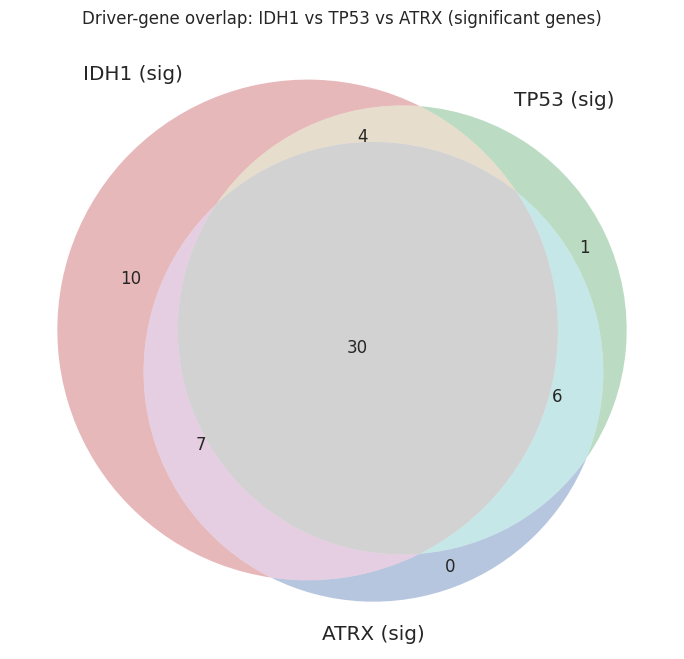

Saved Venn diagram to: /content/drive/MyDrive/TCGA_Mutation_Shift_Biology/Venn_IDH1_TP53_ATRX.png

All outputs saved. If you want FDR-based selection for TP53/ATRX too, set use_fdr_if_available=True for them or adjust p_threshold.


In [ ]:
# Install venn plotting lib (only need to run once)
!pip install matplotlib-venn --quiet

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn3
import os

# -----------------------
# USER CONFIG
# -----------------------
BASE = "/content/drive/MyDrive/TCGA_Mutation_Shift_Biology"   # adjust to your Drive folder
f_idh = os.path.join(BASE, "signature_IDHgene_driver_analysis.csv")
f_tp53 = os.path.join(BASE, "driver_TP53_results_robust.csv")
f_atrx = os.path.join(BASE, "driver_ATRX_results_robust.csv")

# significance threshold (change if you prefer FDR-based filtering)
p_threshold = 0.05
use_fdr_if_available = False   # if IDH file has FDR column and this=True -> uses FDR for IDH selection

# output files
out_venn = os.path.join(BASE, "Venn_IDH1_TP53_ATRX.png")
out_idh_only = os.path.join(BASE, "IDH1_specific_driver_genes.csv")

# -----------------------
# Helper to load a table and extract significant gene set
# handles different p-column names ('p','pvalue') and optional 'FDR'
# -----------------------
def load_and_select(path, pthr=p_threshold, use_fdr=False):
    df = pd.read_csv(path)
    # ensure gene column exists
    if "gene" not in df.columns:
        # try to infer gene column name
        possible = [c for c in df.columns if c.lower() in ("gene","genes","symbol","gene_name")]
        if possible:
            df = df.rename(columns={possible[0]: "gene"})
        else:
            raise ValueError(f"No 'gene' column found in {path}; columns: {list(df.columns)}")
    # choose significance column
    sig_col = None
    if use_fdr and "FDR" in df.columns:
        sig_col = "FDR"
    elif "FDR" in df.columns and df["FDR"].notna().any():
        # prefer FDR if present and requested
        sig_col = "FDR" if use_fdr else None

    # fallback to p or pvalue
    if sig_col is None:
        if "p" in df.columns:
            sig_col = "p"
        elif "pvalue" in df.columns:
            sig_col = "pvalue"
        else:
            # try lowercase variants
            lowcols = {c.lower(): c for c in df.columns}
            if "p" in lowcols:
                sig_col = lowcols["p"]
            elif "pvalue" in lowcols:
                sig_col = lowcols["pvalue"]
            elif "fdr" in lowcols:
                sig_col = lowcols["fdr"]
            else:
                # no p-like column -> treat all genes as "significant" (useful for top20 lists)
                print(f"Warning: no p/FDR column found in {os.path.basename(path)}; treating all rows as significant.")
                return set(df["gene"].astype(str).str.strip())

    # apply threshold
    # coerce to numeric, ignore invalid
    df[sig_col] = pd.to_numeric(df[sig_col], errors="coerce")
    sel = df[df[sig_col] < pthr]
    genes = set(sel["gene"].astype(str).str.strip())
    return genes

# -----------------------
# Load sets
# -----------------------
print("Loading IDH file:", f_idh)
idh_set = load_and_select(f_idh, pthr=p_threshold, use_fdr=use_fdr_if_available)
print("IDH significant genes:", len(idh_set))

print("Loading TP53 file:", f_tp53)
tp53_set = load_and_select(f_tp53, pthr=p_threshold, use_fdr=False)
print("TP53 significant genes:", len(tp53_set))

print("Loading ATRX file:", f_atrx)
atrx_set = load_and_select(f_atrx, pthr=p_threshold, use_fdr=False)
print("ATRX significant genes:", len(atrx_set))

# -----------------------
# Compute IDH-only genes
# -----------------------
idh_only = idh_set - tp53_set - atrx_set
print("\nIDH-only genes (unique to IDH1 sig set):", len(idh_only))
if len(idh_only) > 0:
    print(sorted(list(idh_only)))
else:
    print("No IDH-specific genes found with current thresholds.")

# Save IDH-only CSV
pd.DataFrame({"IDH1_specific_genes": sorted(idh_only)}).to_csv(out_idh_only, index=False)
print("Saved IDH-specific genes to:", out_idh_only)

# -----------------------
# Plot Venn diagram
# -----------------------
plt.figure(figsize=(7,7))
venn3(subsets=(idh_set, tp53_set, atrx_set), set_labels=("IDH1 (sig)", "TP53 (sig)", "ATRX (sig)"))
plt.title("Driver-gene overlap: IDH1 vs TP53 vs ATRX (significant genes)")
plt.tight_layout()
plt.savefig(out_venn, dpi=300)
plt.show()
print("Saved Venn diagram to:", out_venn)

# Done
print("\nAll outputs saved. If you want FDR-based selection for TP53/ATRX too, set use_fdr_if_available=True for them or adjust p_threshold.")